<a href="https://colab.research.google.com/github/Aqillaaprly/PVCK_2025/blob/main/week_10_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage.morphology import skeletonize
from skimage import filters, io, color, morphology

#### Number 3

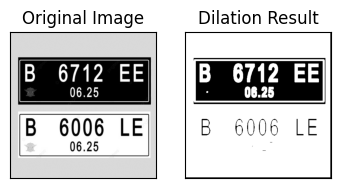

In [ ]:
#Dilation without library
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)

    #Generate structure element dilasi (SED)
    SED= np.ones((w,w), dtype=np.uint8)
    constant1= (w-1)//2

    #Dilation Process
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)

    return imgD

img_d= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img_d, 125, 200, cv2.THRESH_BINARY)
w=5
imgD = dilasi_citra(thresh,w)

plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 4

[[1 1 1]
 [1 1 1]
 [1 1 1]]


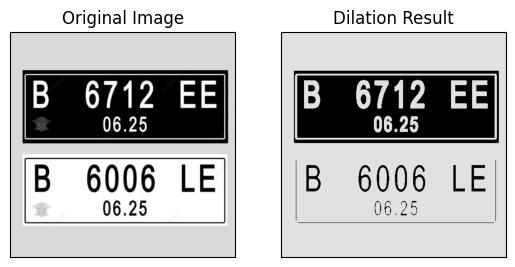

In [ ]:
img = cv2.imread('/content/drive/MyDrive/Images/plat1.jpg')
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint16)
dilasi = cv2.dilate(thresh,kernel,iterations = 1)

print(kernel)
plt.subplot(121),plt.imshow(img),plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dilasi),plt.title('Dilation Result')
plt.xticks([]), plt.yticks([])
plt.show()

#### Number 5

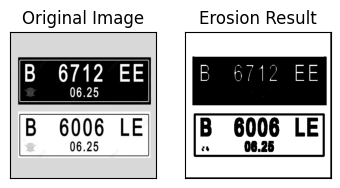

In [ ]:
#Erosion Without Library
def erosi_citra(F,k):
    #size image
    m,n= F.shape

    #Generate structure element erosi (SE)
    SE= np.ones((k,k), dtype=np.uint8)
    constant= (k-1)//2
    imgE= np.zeros((m,n), dtype=np.uint8)

    #Erosion Process
    for i in range(constant, m-constant):
        for j in range(constant,n-constant):
            temp= F[i-constant:i+constant+1, j-constant:j+constant+1]
            product= temp*SE
            imgE[i,j]= np.min(product)

    return imgE

img_e= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret1, thresh1 = cv2.threshold(img_e, 175, 225, cv2.THRESH_BINARY)
k=5
imgE = erosi_citra(thresh1,k)

plt.subplot(131),plt.imshow(img_e,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgE,cmap = 'gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 6

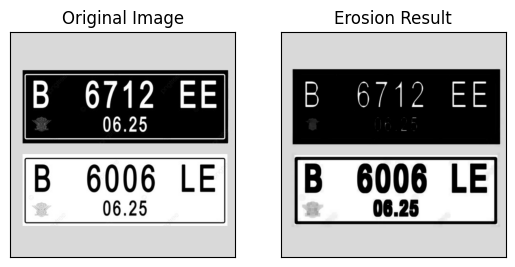

In [ ]:
#EROSION LIBRARY
img = cv2.imread('/content/drive/MyDrive/Images/plat1.jpg')
kernel = np.ones((5,5),np.uint8)
erosion = cv2.erode(img,kernel,iterations = 1)

plt.subplot(121),plt.imshow(img),plt.title('Original Image')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(erosion),plt.title('Erosion Result')
plt.xticks([]), plt.yticks([])
plt.show()

#### Number 7

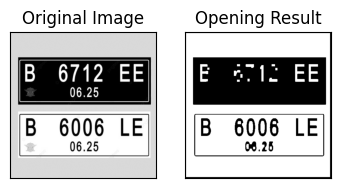

In [ ]:
# Opening Operation Without Using Morphology Library
img_o= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
reto, thresho = cv2.threshold(img_o, 127, 225, cv2.THRESH_BINARY)
k=7
imgO = dilasi_citra(erosi_citra(thresho,k),k)

plt.subplot(131),plt.imshow(img_o,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgO,cmap = 'gray')
plt.title('Opening Result'), plt.xticks([]), plt.yticks([])
plt.show()

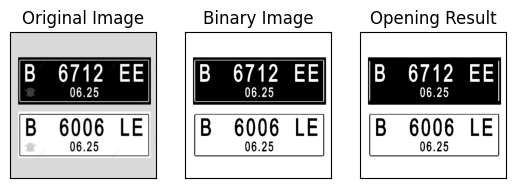

In [ ]:
# Opening Operation Using Morphology Library
#Using Library
img = cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
openn = cv2.morphologyEx(thresh,cv2.MORPH_OPEN, kernel)

plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Binary Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(openn,cmap = 'gray')
plt.title('Opening Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 8

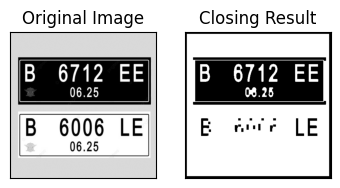

In [ ]:
# Closing operation without morphology library
img_c= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
retc, threshc = cv2.threshold(img_c, 127, 225, cv2.THRESH_BINARY)
k=7
imgC = erosi_citra(dilasi_citra(threshc,k),k)

plt.subplot(131),plt.imshow(img_c,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgC,cmap = 'gray')
plt.title('Closing Result'), plt.xticks([]), plt.yticks([])
plt.show()

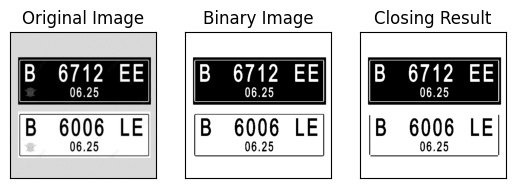

In [ ]:
# Closing operation with morphology library
img = cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img, 127, 225, cv2.THRESH_BINARY)
kernel = np.ones((3,3),np.uint8)
closs = cv2.morphologyEx(thresh,cv2.MORPH_CLOSE, kernel)

plt.subplot(131),plt.imshow(img,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(thresh,cmap = 'gray')
plt.title('Binary Image'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(closs,cmap = 'gray')
plt.title('Closing Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 9

SED = Cross 3


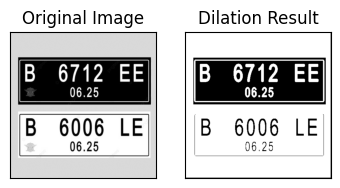

SED = Cross 5


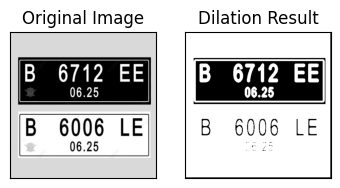

In [ ]:
#Dilation Cross SED
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)

    #Generate structure element dilasi (SED)
    SED = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype = np.uint8)
    constant1= (w-1)//2

    #Dilation Process
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)

    return imgD

print('SED = Cross 3')
img_d= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w=3
imgD = dilasi_citra(thresh,w)

plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)

    #Generate structure element dilasi (SED)
    SED = np.array([[0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0],
                    [1, 1, 1, 1, 1],
                    [0, 0, 1, 0, 0],
                    [0, 0, 1, 0, 0]], dtype = np.uint8)
    constant1= (w-1)//2

    #Dilation Process
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)

    return imgD

print('SED = Cross 5')
img_d= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w=5
imgD = dilasi_citra(thresh,w)

plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 10

SED = Circle 3


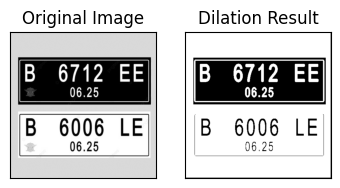

SED = Circle 5


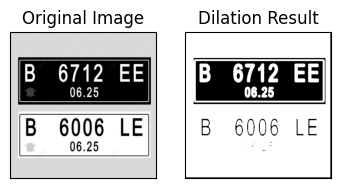

In [ ]:
#Dilation Circular SED
def dilasi_citra(F,w):
    #size image
    p,q= F.shape
    imgD= np.zeros((p,q), dtype=np.uint8)

    #Generate structure element dilasi (SED)
    SED= cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(w,w))
    constant1= (w-1)//2

    #Dilation Process
    for i in range(constant1, p-constant1):
        for j in range(constant1,q-constant1):
            temp= F[i-constant1:i+constant1+1, j-constant1:j+constant1+1]
            product= temp*SED
            imgD[i,j]= np.max(product)

    return imgD

print('SED = Circle 3')
img_d= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w=3
imgD = dilasi_citra(thresh,w)

plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SED = Circle 5')
img_d= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret, thresh = cv2.threshold(img_d, 127, 225, cv2.THRESH_BINARY)
w=5
imgD = dilasi_citra(thresh,w)

plt.subplot(131),plt.imshow(img_d,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgD,cmap = 'gray')
plt.title('Dilation Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 11

SE = Rectangle 3x5


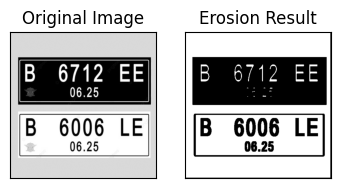

SE = Rectangle 5x7


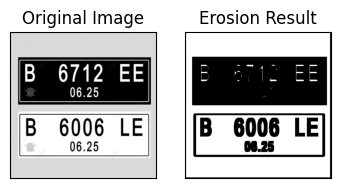

In [ ]:
#Erosion Cross SE
def erosi_citra(F,p,l):
    #size image
    m,n= F.shape

    #Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_RECT,(p,l)) #Rectangle SE
    constant1= (l-1)//2
    constant2= (p-1)//2

    imgE= np.zeros((m,n), dtype=np.uint8)

    #Erosion Process
    for i in range(constant1, m-constant1):
        for j in range(constant2,n-constant2):
            temp= F[i-constant1:i+constant1+1, j-constant2:j+constant2+1]
            product= temp*SE
            imgE[i,j]= np.min(product)

    return imgE

print('SE = Rectangle 3x5')
img_e= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p=5
l=3
imgE = erosi_citra(thresh1,p,l)

plt.subplot(131),plt.imshow(img_e,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgE,cmap = 'gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Rectangle 5x7')
img_e= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
p=7
l=5
imgE = erosi_citra(thresh1,p,l)

plt.subplot(131),plt.imshow(img_e,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgE,cmap = 'gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 12

SE = Vertical Line 3


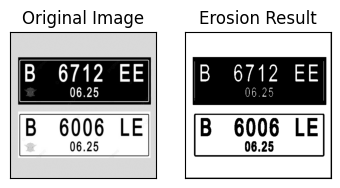

SE = Vertical Line 5


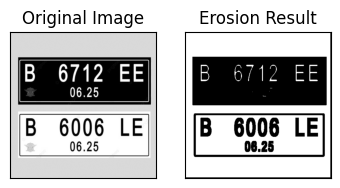

In [ ]:
#Erosion Line Vertical SE
def erosi_citra(F,k):
    #size image
    m,n= F.shape

    #Generate structure element erosi (SE)
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(1,k)) #Vertical line SE
    constant= (k-1)//2
    imgE= np.zeros((m,n), dtype=np.uint8)

    #Erosion Process
    for i in range(constant, m-constant):
        for j in range(constant,n-constant):
            temp= F[i-constant:i+constant+1, j-constant:j+constant+1]
            product= temp*SE
            imgE[i,j]= np.min(product)

    return imgE

print('SE = Vertical Line 3')
img_e= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k=3
imgE = erosi_citra(thresh1,k)

plt.subplot(131),plt.imshow(img_e,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgE,cmap = 'gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

print('SE = Vertical Line 5')
img_e= cv2.imread('/content/drive/MyDrive/Images/plat1.jpg',0)
ret1, thresh1 = cv2.threshold(img_e, 127, 225, cv2.THRESH_BINARY)
k=5
imgE = erosi_citra(thresh1,k)

plt.subplot(131),plt.imshow(img_e,cmap = 'gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(imgE,cmap = 'gray')
plt.title('Erosion Result'), plt.xticks([]), plt.yticks([])
plt.show()

#### Number 13

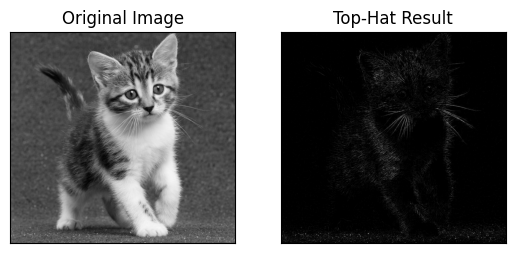

In [ ]:
# kernel
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Read Image
img = cv2.imread('/content/drive/MyDrive/Images/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Top-Hat
tophat_img = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)

# Result
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(tophat_img, cmap='gray')
plt.title('Top-Hat Result'), plt.xticks([]), plt.yticks([])

plt.show()

#### Number 14

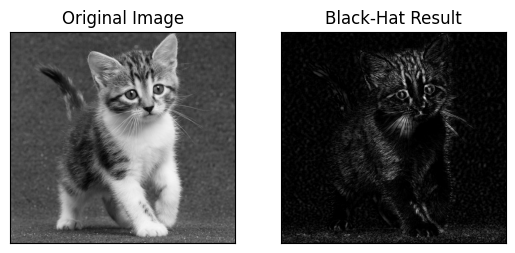

In [ ]:
# kernel
filterSize = (3, 3)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, filterSize)

# Read Image
img = cv2.imread('/content/drive/MyDrive/Images/kitten01.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Black-Hat with bigger kernel (13x5)
Kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, Kernel)

# Show result
plt.subplot(121), plt.imshow(img_gray, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(blackhat, cmap='gray')
plt.title('Black-Hat Result'), plt.xticks([]), plt.yticks([])

plt.show()

#### Number 15

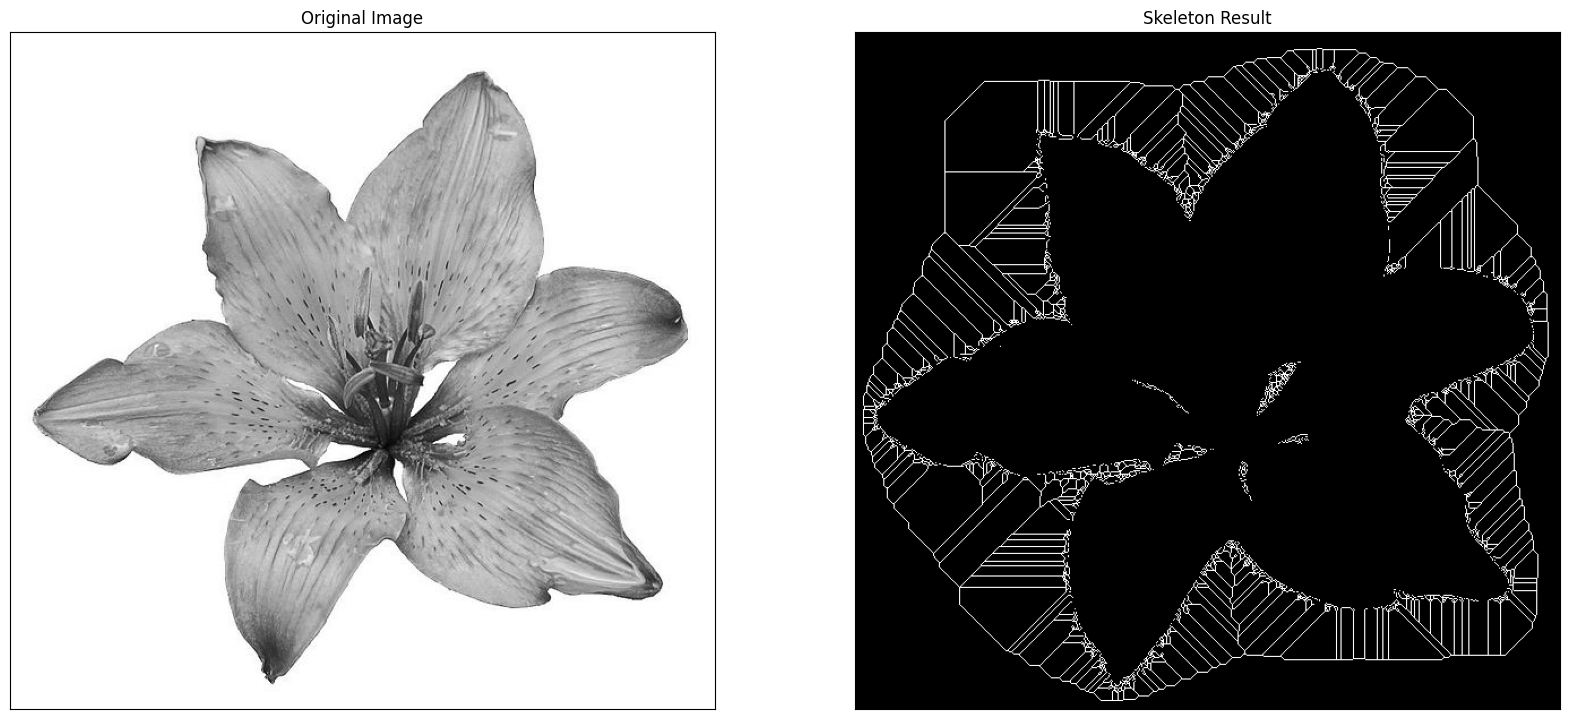

In [ ]:
import cv2 as cv
from matplotlib import pyplot as plt
from skimage import filters
from skimage.morphology import skeletonize

# Read image in grayscale
img = cv.imread('/content/drive/MyDrive/Images/lily.jpg', 0)

# Change the binary with triangle threshold
binary = img > filters.threshold_triangle(img)

# True/False to 1/0
binary_cp = binary.copy()
binary_cp[binary_cp == True] = 1
binary_cp[binary_cp == False] = 0

# skeletonization
skeleton = skeletonize(binary_cp)

# Show Result
plt.figure(figsize=(20, 20))
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Result'), plt.xticks([]), plt.yticks([])

# Save to File
plt.savefig("binary_and_bin_skeleton.png")
plt.show()


#### Number 16

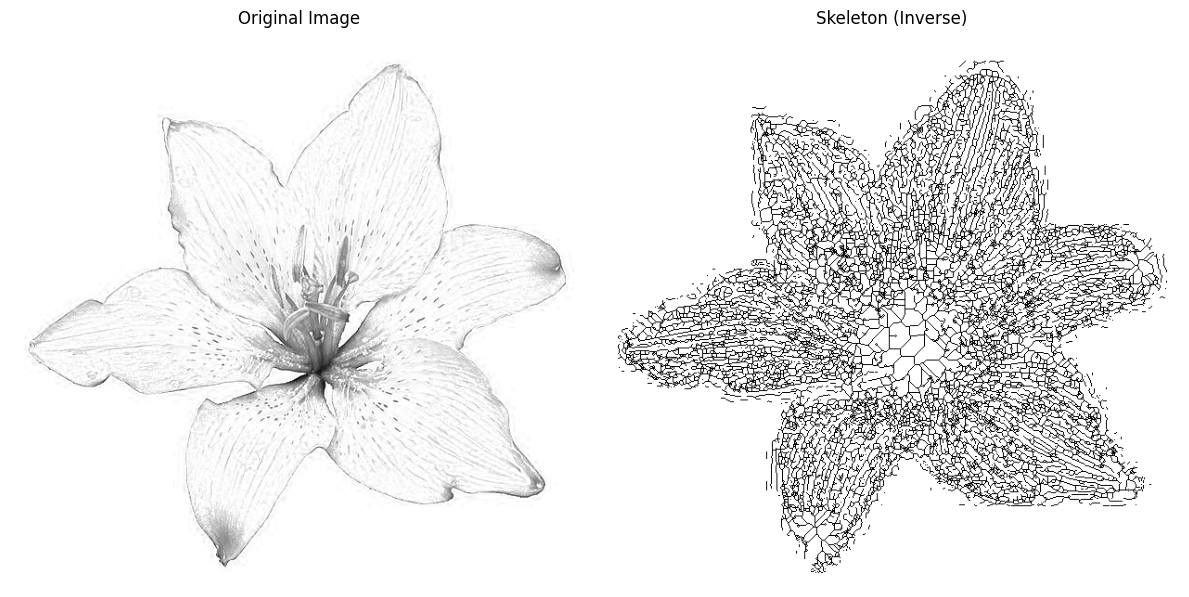

In [ ]:
from skimage import io, filters
from skimage.morphology import skeletonize
from matplotlib import pyplot as plt

# Read image
img = io.imread('/content/drive/MyDrive/Images/lily.jpg')[..., 0]

# Binary Image
binary = img < filters.threshold_triangle(img)

# skeletonization
skeleton = skeletonize(binary)

# Show Result
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original Image')
ax[0].set_axis_off()

# gray_r
ax[1].imshow(skeleton, cmap='gray_r')
ax[1].set_title('Skeleton (Inverse)')
ax[1].set_axis_off()

plt.tight_layout()
plt.show()


#### Number 17

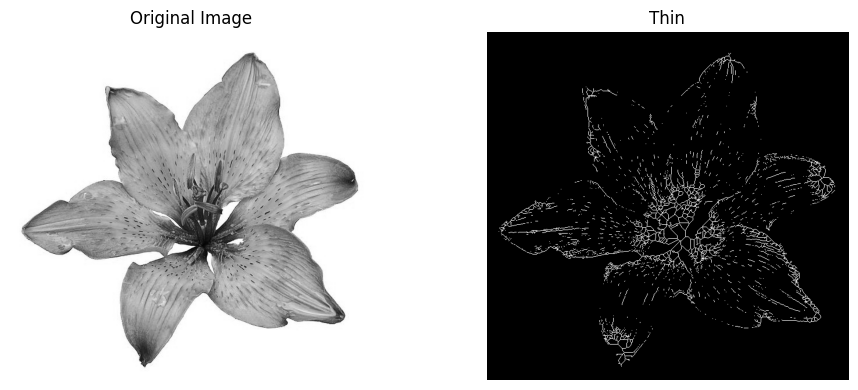

In [ ]:
from skimage import io, color, morphology, img_as_float
import matplotlib.pyplot as plt

# Read image
image = img_as_float(color.rgb2gray(io.imread('/content/drive/MyDrive/Images/lily.jpg')))

# Binary Image
image_binary = image < 0.5

# skeletonize and thinning
out_skeletonize = morphology.skeletonize(image_binary)
out_thin = morphology.thin(image_binary)

# Show Result
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))

ax0.imshow(image, cmap='gray')
ax0.set_title('Original Image')
ax0.axis('off')

ax1.imshow(out_thin, cmap='gray')
ax1.set_title('Thin')
ax1.axis('off')

plt.tight_layout()
plt.savefig('/tmp/char_out.png')
plt.show()
